# 📘 Week 6 Assignment — Denoising Autoencoder on MNIST
## Autoencoder for Image Denoising



# 1 — Imports & Setup

In [1]:
# Install scikit-image if not already present (for PSNR / SSIM)
# !pip install scikit-image -q

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D,
    BatchNormalization, Conv2DTranspose
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

print("TensorFlow version:", tf.__version__)
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.20.0


# 2 — Data Preparation

### 2.1 Load & Normalise MNIST
MNIST contains 60 000 training and 10 000 test grayscale images (28×28 pixels).
Pixel values are normalised from `[0, 255]` → `[0.0, 1.0]` so the model's sigmoid
output layer and the MSE loss both operate on the same scale.

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalise to [0, 1] and add channel dimension → (N, 28, 28, 1)
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0
x_train = x_train[..., np.newaxis]
x_test  = x_test[..., np.newaxis]

print('Training set :', x_train.shape, '  dtype:', x_train.dtype)
print('Test set     :', x_test.shape,  '  dtype:', x_test.dtype)
print('Pixel range  : [{:.1f}, {:.1f}]'.format(x_train.min(), x_train.max()))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set : (60000, 28, 28, 1)   dtype: float32
Test set     : (10000, 28, 28, 1)   dtype: float32
Pixel range  : [0.0, 1.0]


### 2.2 Add Gaussian Noise
We corrupt each image with Gaussian noise (mean = 0, std = `NOISE_FACTOR = 0.4`).
`np.clip` ensures values stay in `[0, 1]`.

The autoencoder is trained with **noisy images as input** and **clean images as target** —
this forces it to learn to denoise rather than memorise an identity function.

Noisy train : (60000, 28, 28, 1)
Noisy test  : (10000, 28, 28, 1)


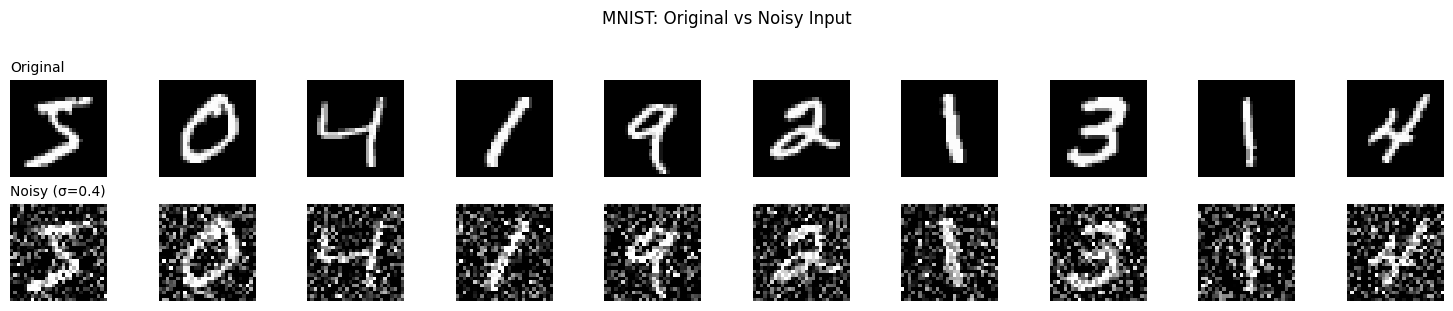

In [3]:
NOISE_FACTOR = 0.4   # σ of Gaussian noise added

x_train_noisy = np.clip(
    x_train + NOISE_FACTOR * np.random.randn(*x_train.shape), 0.0, 1.0
).astype('float32')

x_test_noisy = np.clip(
    x_test + NOISE_FACTOR * np.random.randn(*x_test.shape), 0.0, 1.0
).astype('float32')

print('Noisy train :', x_train_noisy.shape)
print('Noisy test  :', x_test_noisy.shape)

# Quick visualisation of noise effect
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0, i].imshow(x_train[i, ..., 0], cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_train_noisy[i, ..., 0], cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_title('Original', loc='left', fontsize=10)
axes[1, 0].set_title('Noisy (σ=0.4)', loc='left', fontsize=10)
plt.suptitle('MNIST: Original vs Noisy Input', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# 3 — Model Architecture: Convolutional Denoising Autoencoder

A **Convolutional Denoising Autoencoder (CDAE)** has two halves:

| Part | Layers | Role |
|------|--------|------|
| **Encoder** | Conv2D → BN → MaxPool (×2) | Compress the 28×28 image down to a 7×7×64 latent map |
| **Decoder** | Conv2DTranspose → BN → UpSampling (×2) | Reconstruct 28×28 clean image from the latent map |

**Why convolutions?** Convolutional kernels share weights spatially and exploit the fact that adjacent
pixels are correlated, making them far more efficient than Dense layers for image tasks.

**Why BatchNormalization?** Normalising activations after each layer stabilises training and
allows higher learning rates, reducing the number of epochs needed.

**Why `sigmoid` at the output?** MNIST pixel values are in `[0, 1]`, and sigmoid maps any real
value to this range, ensuring the reconstructed image is in the same space as the clean target.

**Bottleneck (7×7×64):** The encoder compresses 28×28×1 = 784 values into 7×7×64 = 3136 values.
Although 3136 > 784 here (unlike a typical compressive autoencoder), the two MaxPooling layers
force the network to learn *spatial* features, not a pixel-wise identity mapping —
the Gaussian noise is thus forced out during reconstruction.

In [4]:
def build_denoising_autoencoder():
    inp = Input(shape=(28, 28, 1), name='noisy_input')

    # ── Encoder ──────────────────────────────────
    x = Conv2D(32, (3, 3), activation='relu', padding='same', name='enc_conv1')(inp)
    x = BatchNormalization(name='enc_bn1')(x)
    x = MaxPooling2D((2, 2), padding='same', name='enc_pool1')(x)   # → 14×14×32

    x = Conv2D(64, (3, 3), activation='relu', padding='same', name='enc_conv2')(x)
    x = BatchNormalization(name='enc_bn2')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name='latent')(x) # → 7×7×64

    # ── Decoder ──────────────────────────────────
    x = Conv2DTranspose(64, (3, 3), activation='relu', padding='same', name='dec_conv1')(encoded)
    x = BatchNormalization(name='dec_bn1')(x)
    x = UpSampling2D((2, 2), name='dec_up1')(x)                     # → 14×14×64

    x = Conv2DTranspose(32, (3, 3), activation='relu', padding='same', name='dec_conv2')(x)
    x = BatchNormalization(name='dec_bn2')(x)
    x = UpSampling2D((2, 2), name='dec_up2')(x)                     # → 28×28×32

    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='clean_output')(x)

    return Model(inp, decoded, name='DenoisingAutoencoder')


dae = build_denoising_autoencoder()
dae.summary()

Model: "DenoisingAutoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn1 (BatchNormalization)    │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn2 (BatchNormalization)    │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (MaxPooling2D)           │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2DTranspose)     │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn1 (BatchNormalization)    │ (None, 7, 7, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up1 (UpSampling2D)          │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2DTranspose)     │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn2 (BatchNormalization)    │ (None, 14, 14, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up2 (UpSampling2D)          │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clean_output (Conv2D)           │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,265 (294.00 KB)

 Trainable params: 74,881 (292.50 KB)

 Non-trainable params: 384 (1.50 KB)

# 4 — Training Setup

| Hyperparameter | Value | Reason |
|----------------|-------|--------|
| Loss | `mse` (Mean Squared Error) | Pixel-wise reconstruction error; standard for autoencoders |
| Optimiser | `Adam` (lr=0.001) | Adaptive learning rate; fast and robust |
| Batch size | 256 | Large batches → stable gradient estimates on MNIST |
| Max epochs | 50 | EarlyStopping will terminate earlier if val_loss plateaus |
| EarlyStopping | patience=5, restore best weights | Prevents overfitting, saves best model automatically |
| ReduceLROnPlateau | patience=3, factor=0.5 | Halves lr when stuck; helps escape flat loss regions |

**Input → Target pairing:**  `(x_train_noisy, x_train)` — the model sees corrupted images
and learns to output clean ones. Validation split of 10% tracks generalisation.

In [ ]:
dae.compile(optimizer='adam', loss='mse')

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True,
                  verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                      min_lr=1e-6, verbose=1)
]

history = dae.fit(
    x_train_noisy, x_train,          # noisy → clean
    epochs=50,
    batch_size=256,
    validation_split=0.10,
    callbacks=callbacks,
    verbose=1
)

print('\nTraining complete. Epochs run:', len(history.history['loss']))

Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 113s 526ms/step - loss: 0.0357 - val_loss: 0.8352 - learning_rate: 0.0010
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 132s 481ms/step - loss: 0.0118 - val_loss: 0.1487 - learning_rate: 0.0010
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 107s 509ms/step - loss: 0.0096 - val_loss: 0.0100 - learning_rate: 0.0010
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 139s 496ms/step - loss: 0.0089 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 142s 499ms/step - loss: 0.0085 - val_loss: 0.0084 - learning_rate: 0.0010
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 146s 518ms/step - loss: 0.0083 - val_loss: 0.0082 - learning_rate: 0.0010
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 144s 526ms/step - loss: 0.0080 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 114s 542ms/step - loss: 0.0079 - val_loss: 0.0079 - learning_rate: 0.0010
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 112s 532ms/step - loss: 0.0078 - val_loss: 0.007

In [ ]:
# Plot training & validation loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss — Denoising Autoencoder')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5 — Evaluation & Denoised Output

### 5.1 Reconstruct Test Set
Run the trained autoencoder on the **test-set noisy images** to produce denoised reconstructions.

In [ ]:
# Reconstruct test images
x_test_denoised = dae.predict(x_test_noisy, verbose=1)

test_mse = dae.evaluate(x_test_noisy, x_test, verbose=0)
print(f'\nTest MSE (noisy→clean): {test_mse:.6f}')

### 5.2 PSNR & SSIM Metrics

Two perceptual quality metrics are computed on 500 test images:

| Metric | What it measures | Higher is better? |
|--------|-----------------|-------------------|
| **PSNR** (Peak Signal-to-Noise Ratio) | Log ratio of signal power to noise power (dB) | ✅ Yes |
| **SSIM** (Structural Similarity Index) | Luminance, contrast and structure similarity in [0,1] | ✅ Yes |

In [ ]:
N_EVAL = 500

psnr_noisy  = np.mean([psnr(x_test[i,...,0], x_test_noisy[i,...,0])      for i in range(N_EVAL)])
psnr_denoised = np.mean([psnr(x_test[i,...,0], x_test_denoised[i,...,0]) for i in range(N_EVAL)])

ssim_noisy  = np.mean([ssim(x_test[i,...,0], x_test_noisy[i,...,0],      data_range=1.0) for i in range(N_EVAL)])
ssim_denoised = np.mean([ssim(x_test[i,...,0], x_test_denoised[i,...,0], data_range=1.0) for i in range(N_EVAL)])

metrics_df = pd.DataFrame({
    'Image Type': ['Noisy Input', 'Denoised Output'],
    'PSNR (dB)' : [round(psnr_noisy, 2),    round(psnr_denoised, 2)],
    'SSIM'      : [round(ssim_noisy, 4),     round(ssim_denoised, 4)]
})
print(metrics_df.to_string(index=False))

# 6 — Visualisation: Original / Noisy / Denoised

The three-row grid below is the **primary qualitative check** required by the evaluator.
Each column shows one MNIST test digit across all three states.

In [ ]:
N_DISPLAY = 10
fig, axes = plt.subplots(3, N_DISPLAY, figsize=(15, 5))

titles = ['Original (clean)', 'Noisy Input', 'Denoised Output']
images = [x_test, x_test_noisy, x_test_denoised]

for row, (title, imgs) in enumerate(zip(titles, images)):
    for col in range(N_DISPLAY):
        axes[row, col].imshow(imgs[col, ..., 0], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(title, fontsize=10, rotation=0, labelpad=90)

plt.suptitle('Denoising Autoencoder — Test Set Results', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Per-class PSNR bar chart (one bar per digit 0-9)
class_psnr = {}
for digit in range(10):
    idx = np.where(y_test == digit)[0][:50]   # 50 samples per class
    class_psnr[digit] = np.mean(
        [psnr(x_test[i,...,0], x_test_denoised[i,...,0]) for i in idx]
    )

plt.figure(figsize=(8, 4))
plt.bar(class_psnr.keys(), class_psnr.values(), color='steelblue', edgecolor='black')
plt.axhline(psnr_denoised, color='red', linestyle='--', label=f'Overall mean {psnr_denoised:.2f} dB')
plt.xlabel('Digit Class')
plt.ylabel('PSNR (dB)')
plt.title('Per-Digit Denoising Quality (PSNR)')
plt.xticks(range(10))
plt.legend()
plt.tight_layout()
plt.show()